# Оптика биотканей — решение семинара
**Биофизика, дополнительный семинар**

Темы: спектры хромофоров · сборка оптических свойств ткани · диффузное приближение · Монте-Карло · уравнение Пеннеса · интеграл Аррениуса

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Загрузка спектров хромофоров

Используем готовые CSV-файлы из папки семинара:
- `hb.csv`, `hbo2.csv` — молярная экстинкция гемоглобина (см⁻¹·М⁻¹)
- `water.csv` — коэффициент поглощения воды (см⁻¹)
- `fat.csv` — коэффициент поглощения жира (см⁻¹)
- `melanin.csv` — аналитическая модель меланина (см⁻¹)

In [32]:
hb    = pd.read_csv('hb.csv')
hbo2  = pd.read_csv('hbo2.csv')
water = pd.read_csv('water.csv')
fat   = pd.read_csv('fat.csv')
mel   = pd.read_csv('melanin.csv')

for name, df in [('Hb', hb), ('HbO2', hbo2), ('water', water), ('fat', fat), ('melanin', mel)]:
    wl = df['wavelength_nm']
    print(f'{name:8s}: {len(df):4d} точек, λ = {wl.min():.0f}–{wl.max():.0f} нм')

Hb      :   70 точек, λ = 408–980 нм
HbO2    :  231 точек, λ = 400–1000 нм
water   :   41 точек, λ = 400–1000 нм
fat     :  572 точек, λ = 429–1000 нм
melanin :  601 точек, λ = 400–1000 нм


### 1.1 Визуализация спектров

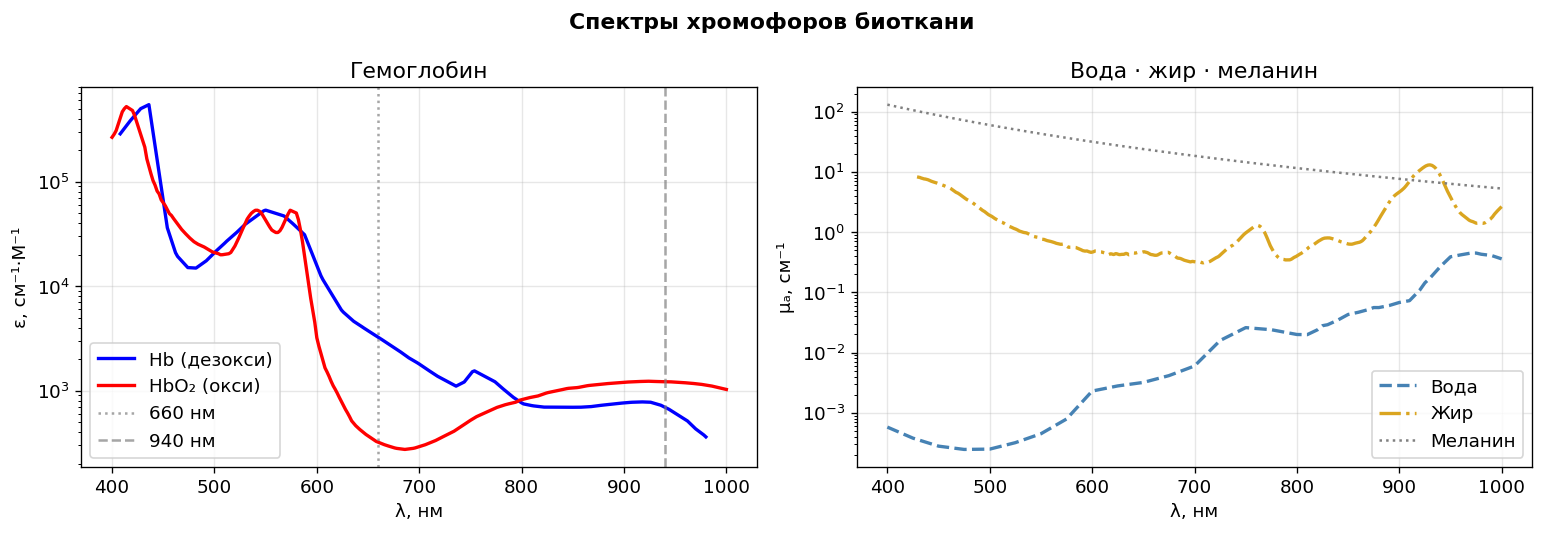

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Гемоглобин
ax1.semilogy(hb['wavelength_nm'],   hb['epsilon_cm_M'],   'b-',  lw=2, label='Hb (дезокси)')
ax1.semilogy(hbo2['wavelength_nm'], hbo2['epsilon_cm_M'], 'r-',  lw=2, label='HbO₂ (окси)')
ax1.axvline(660, color='gray', ls=':', alpha=0.7, label='660 нм')
ax1.axvline(940, color='gray', ls='--', alpha=0.7, label='940 нм')
ax1.set_xlabel('λ, нм'); ax1.set_ylabel('ε, см⁻¹·М⁻¹')
ax1.set_title('Гемоглобин'); ax1.legend(); ax1.grid(alpha=0.3)

# Остальные хромофоры
ax2.semilogy(water['wavelength_nm'], water['mu_a_cm'], 'steelblue', lw=2, ls='--', label='Вода')
ax2.semilogy(fat['wavelength_nm'],   fat['mu_a_cm'],   'goldenrod', lw=2, ls='-.', label='Жир')
ax2.semilogy(mel['wavelength_nm'],   mel['mu_a_cm'],   'gray',      lw=1.5, ls=':', label='Меланин')
ax2.set_xlabel('λ, нм'); ax2.set_ylabel('μₐ, см⁻¹')
ax2.set_title('Вода · жир · меланин'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Спектры хромофоров биоткани', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Сборка оптических свойств ткани

**Коэффициент поглощения** (суперпозиция хромофоров):

$$\mu_a^{tissue}(\lambda) = B\bigl[S\,\mu_a^{HbO_2} + (1-S)\,\mu_a^{Hb}\bigr] + W\,\mu_a^{water} + F\,\mu_a^{fat} + M\,\mu_a^{melanin}$$

Молярную экстинкцию переводим в μₐ по формуле OMLC:
$$\mu_a^{Hb} = 2.303\,\varepsilon\cdot\frac{150\text{ г/л}}{64500\text{ г/моль}}$$

**Транспортный коэффициент рассеяния** (закон Жака 2013):
$$\mu_s'(\lambda) = a'\Bigl[f_{Ray}\bigl(\tfrac{\lambda}{500}\bigr)^{-4} + (1-f_{Ray})\bigl(\tfrac{\lambda}{500}\bigr)^{-b_{Mie}}\Bigr]$$

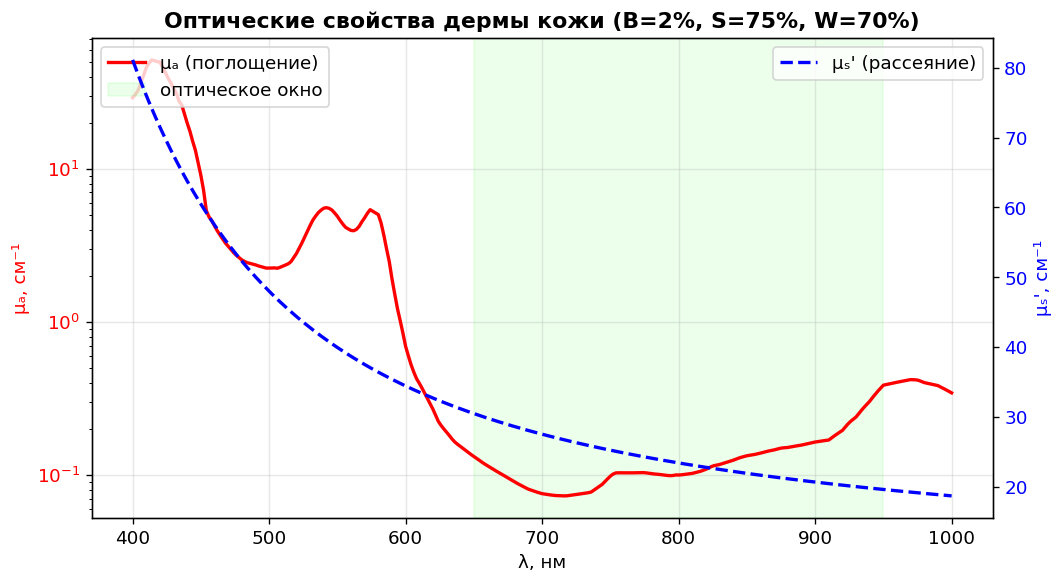

In [34]:
BLOOD_CONV = 2.303 * (150.0 / 64500.0)  # ε [см⁻¹·М⁻¹] → μa [см⁻¹] для цельной крови

def interp(df, wl, col=None):
    col = col or df.columns[1]
    return np.interp(wl, df['wavelength_nm'], df[col])

def tissue_optics(wl, B=0.02, S=0.75, W=0.70, F=0.0, M=0.0,
                  a_prime=48.0, f_ray=0.41, b_mie=0.70):
    """Возвращает (mu_a, mu_s') в см⁻¹ для массива длин волн wl."""
    mu_a = (
        B * (S * interp(hbo2, wl) + (1-S) * interp(hb, wl)) * BLOOD_CONV
        + W * interp(water, wl, 'mu_a_cm')
        + F * interp(fat,   wl, 'mu_a_cm')
        + M * interp(mel,   wl, 'mu_a_cm')
    )
    lam_n = wl / 500.0
    mu_sp = a_prime * (f_ray * lam_n**-4 + (1 - f_ray) * lam_n**-b_mie)
    return mu_a, mu_sp

wl = np.arange(400, 1001, 2, dtype=float)

# Дерма кожи (параметры Jacques 2013)
mu_a_skin, mu_sp_skin = tissue_optics(wl)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.semilogy(wl, mu_a_skin, 'r-', lw=2, label='μₐ (поглощение)')
ax1.set_xlabel('λ, нм'); ax1.set_ylabel('μₐ, см⁻¹', color='r')
ax1.tick_params('y', labelcolor='r'); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(wl, mu_sp_skin, 'b--', lw=2, label="μₛ' (рассеяние)")
ax2.set_ylabel("μₛ', см⁻¹", color='b'); ax2.tick_params('y', labelcolor='b')
ax1.axvspan(650, 950, color='lime', alpha=0.08, label='оптическое окно')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.title('Оптические свойства дермы кожи (B=2%, S=75%, W=70%)', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Ответы на вопросы семинара

### Вопрос 1: При какой λ поглощение воды превышает поглощение гемоглобина в дерме?

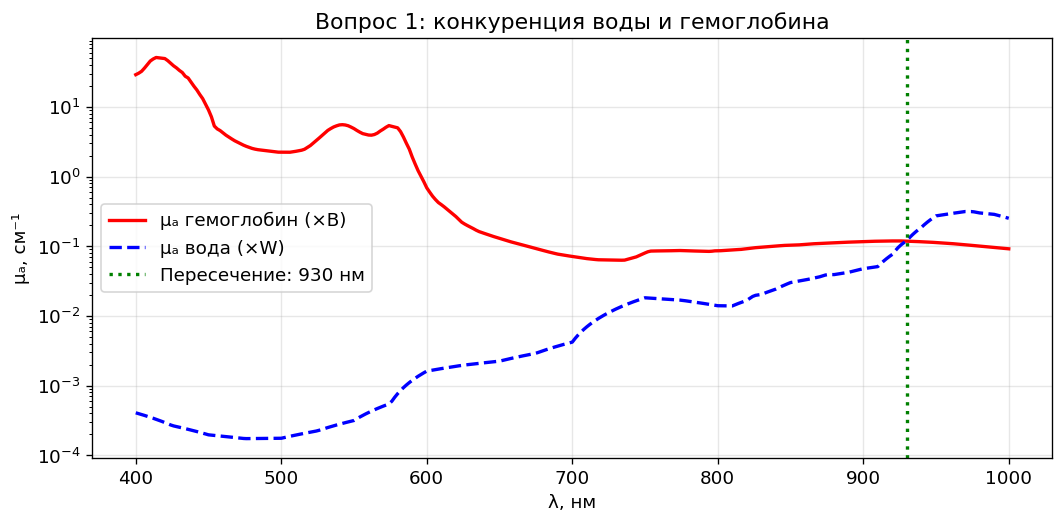


Вывод: при λ ≈ 930 нм поглощение воды превышает поглощение гемоглобина.
При лазерной коагуляции глубоких структур нужно выбирать λ < этого значения,
иначе излучение будет поглощаться водой ещё в поверхностных слоях дермы.


In [35]:
B, S, W = 0.02, 0.75, 0.70

mua_hb_tissue  = B * (S * interp(hbo2, wl) + (1-S) * interp(hb, wl)) * BLOOD_CONV
mua_water_tissue = W * interp(water, wl, 'mu_a_cm')

# Первая точка, где вода начинает превышать Hb
cross_idx = np.where(mua_water_tissue > mua_hb_tissue)[0]
# Берём только в красно-ИК диапазоне (>600 нм) — биологически важная область
cross_idx_nir = cross_idx[wl[cross_idx] > 600]
wl_cross = wl[cross_idx_nir[0]] if len(cross_idx_nir) else None

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(wl, mua_hb_tissue,    'r-',  lw=2, label='μₐ гемоглобин (×B)')
ax.semilogy(wl, mua_water_tissue, 'b--', lw=2, label='μₐ вода (×W)')
if wl_cross:
    ax.axvline(wl_cross, color='green', ls=':', lw=2,
               label=f'Пересечение: {wl_cross:.0f} нм')
ax.set_xlabel('λ, нм'); ax.set_ylabel('μₐ, см⁻¹')
ax.set_title('Вопрос 1: конкуренция воды и гемоглобина')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nВывод: при λ ≈ {wl_cross:.0f} нм поглощение воды превышает поглощение гемоглобина.')
print('При лазерной коагуляции глубоких структур нужно выбирать λ < этого значения,')
print('иначе излучение будет поглощаться водой ещё в поверхностных слоях дермы.')

### Вопрос 2: Чувствительность к гипоксии. Почему пульсоксиметры используют 660/940 нм?

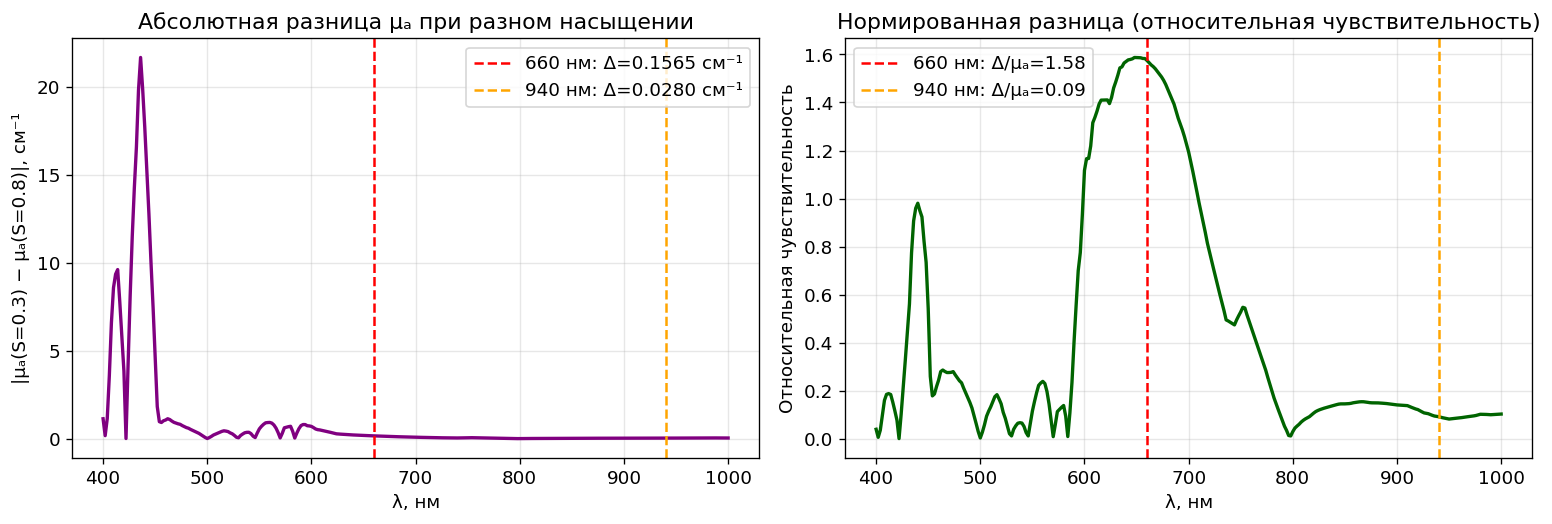

Максимум Δμₐ при λ = 436 нм  (21.6805 см⁻¹)

Почему 660/940 нм в пульсоксиметре:
  • 660 нм (красный): Hb >> HbO₂ — высокая чувствительность к SaO₂
  • 940 нм (ближний ИК): HbO₂ ≈ Hb — изобестическая точка для нормировки
  • Оба в «оптическом окне» — достаточная глубина проникновения
  • Отношение R = (A660/A940) однозначно кодирует SaO₂ через закон Бугера-Ламберта-Бера


In [36]:
mu_a_low,  _ = tissue_optics(wl, B=B, S=0.3, W=W)
mu_a_high, _ = tissue_optics(wl, B=B, S=0.8, W=W)
delta_mua = np.abs(mu_a_low - mu_a_high)

# Нормированная разница — относительная чувствительность
rel_delta = delta_mua / (mu_a_high + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(wl, delta_mua, 'purple', lw=2)
for lam, c in [(660, 'red'), (940, 'orange')]:
    v = np.interp(lam, wl, delta_mua)
    axes[0].axvline(lam, color=c, ls='--', label=f'{lam} нм: Δ={v:.4f} см⁻¹')
axes[0].set_xlabel('λ, нм'); axes[0].set_ylabel('|μₐ(S=0.3) − μₐ(S=0.8)|, см⁻¹')
axes[0].set_title('Абсолютная разница μₐ при разном насыщении')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(wl, rel_delta, 'darkgreen', lw=2)
for lam, c in [(660, 'red'), (940, 'orange')]:
    v = np.interp(lam, wl, rel_delta)
    axes[1].axvline(lam, color=c, ls='--', label=f'{lam} нм: Δ/μₐ={v:.2f}')
axes[1].set_xlabel('λ, нм'); axes[1].set_ylabel('Относительная чувствительность')
axes[1].set_title('Нормированная разница (относительная чувствительность)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Точки максимума
idx_max = np.argmax(delta_mua)
print(f'Максимум Δμₐ при λ = {wl[idx_max]:.0f} нм  ({delta_mua[idx_max]:.4f} см⁻¹)')
print()
print('Почему 660/940 нм в пульсоксиметре:')
print('  • 660 нм (красный): Hb >> HbO₂ — высокая чувствительность к SaO₂')
print('  • 940 нм (ближний ИК): HbO₂ ≈ Hb — изобестическая точка для нормировки')
print('  • Оба в «оптическом окне» — достаточная глубина проникновения')
print('  • Отношение R = (A660/A940) однозначно кодирует SaO₂ через закон Бугера-Ламберта-Бера')

### Вопрос 3: Оптическое окно — где μₐ < 1 см⁻¹ и μₛ' > 10 см⁻¹?

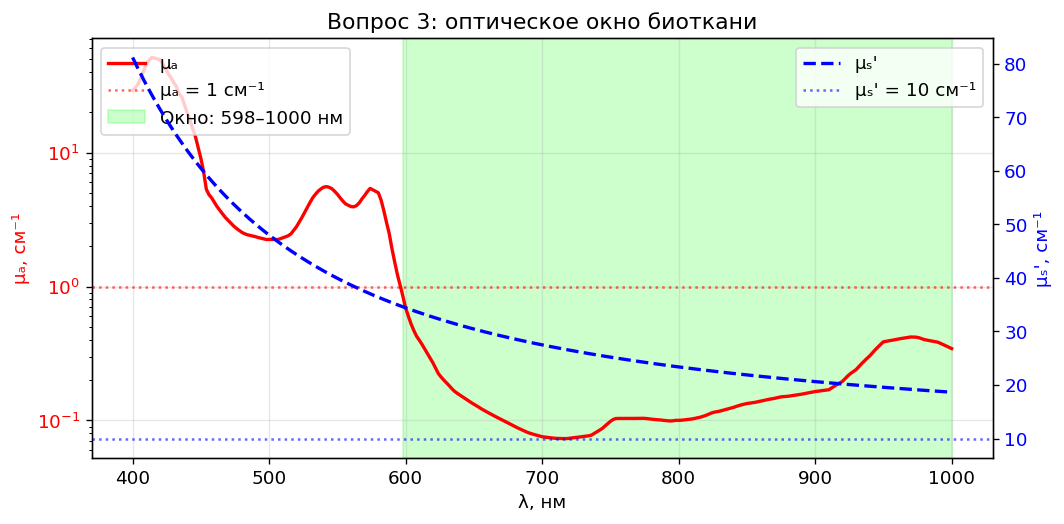

Оптическое окно: 598 – 1000 нм

Почему это условие важно для диффузного приближения:
  • μₐ < μₛ'  →  фотоны рассеиваются намного чаще, чем поглощаются
  • Только при этом условии диффузное приближение P₁ применимо
  • Длина диффузии δ = 1/μ_eff >> 1/μₜ, перенос многократно рассеянный
  • Глубина проникновения δ = 1/√(3μₐ(μₐ+μₛ')) максимальна в этом окне


In [37]:
window_mask = (mu_a_skin < 1.0) & (mu_sp_skin > 10.0)
wl_window = wl[window_mask]

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.semilogy(wl, mu_a_skin,  'r-',  lw=2, label='μₐ')
ax1.axhline(1.0, color='red', ls=':', alpha=0.6, label='μₐ = 1 см⁻¹')
ax1.set_ylabel('μₐ, см⁻¹', color='r'); ax1.tick_params('y', labelcolor='r')
ax2 = ax1.twinx()
ax2.plot(wl, mu_sp_skin, 'b--', lw=2, label="μₛ'")
ax2.axhline(10.0, color='blue', ls=':', alpha=0.6, label="μₛ' = 10 см⁻¹")
ax2.set_ylabel("μₛ', см⁻¹", color='b'); ax2.tick_params('y', labelcolor='b')

if len(wl_window):
    ax1.axvspan(wl_window[0], wl_window[-1], color='lime', alpha=0.2,
                label=f'Окно: {wl_window[0]:.0f}–{wl_window[-1]:.0f} нм')

ax1.set_xlabel('λ, нм')
ax1.set_title('Вопрос 3: оптическое окно биоткани')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
ax1.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'Оптическое окно: {wl_window[0]:.0f} – {wl_window[-1]:.0f} нм')
print()
print('Почему это условие важно для диффузного приближения:')
print('  • μₐ < μₛ\'  →  фотоны рассеиваются намного чаще, чем поглощаются')
print('  • Только при этом условии диффузное приближение P₁ применимо')
print('  • Длина диффузии δ = 1/μ_eff >> 1/μₜ, перенос многократно рассеянный')
print('  • Глубина проникновения δ = 1/√(3μₐ(μₐ+μₛ\')) максимальна в этом окне')

## 4. Диффузное приближение (1D, граничные условия Робина)

Уравнение диффузии для стационарного флюенса $\Phi_d(z)$:
$$D\frac{d^2\Phi_d}{dz^2} - \mu_a\Phi_d = -\mu_s'\Phi_0 e^{-\mu_t z}, \quad D = \frac{1}{3(\mu_a+\mu_s')}$$

Граничные условия 3-го рода (Робина): $\Phi_d \mp 2AD\frac{d\Phi_d}{dz}\big|_{z=0,L} = 0$

Общее решение: $\Phi_d(z) = C_1 e^{\mu_{eff}z} + C_2 e^{-\mu_{eff}z} + K e^{-\mu_t z}$

/tmp/ipykernel_13636/2524050892.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mua, msp = float(mua), float(msp)


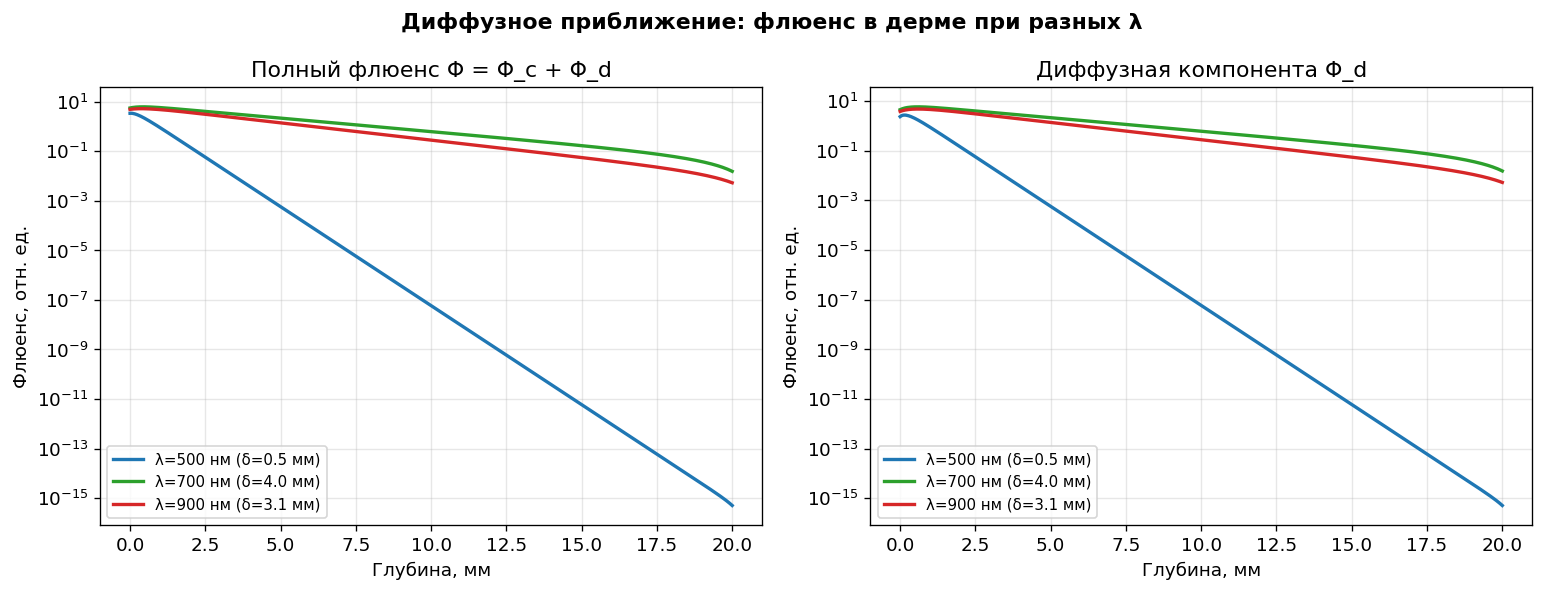

Вывод: чем глубже в оптическое окно (700–900 нм), тем больше δ — тем глубже проникает свет.


In [38]:
def fluence_diffusion(mu_a, mu_sp, L_cm=2.0, R_eff=0.493, n_z=500):
    """Аналитическое решение уравнения диффузии с граничными условиями Робина."""
    mu_t  = mu_a + mu_sp
    D     = 1.0 / (3.0 * mu_t)
    mu_eff = np.sqrt(mu_a / D)
    A     = (1 + R_eff) / (1 - R_eff)
    beta  = 2 * A * D

    # Амплитуда частного решения
    denom = mu_a - D * mu_t**2
    if abs(denom) < 1e-12:
        denom = 1e-12
    K = mu_sp / denom  # Φ₀ = 1 Вт/см²

    # Система для C1, C2 из граничных условий
    eL = np.exp(mu_eff * L_cm)
    emL = np.exp(-mu_eff * L_cm)
    etL = np.exp(-mu_t * L_cm)
    M = np.array([
        [1 - beta * mu_eff,        1 + beta * mu_eff],
        [eL * (1 + beta * mu_eff), emL * (1 - beta * mu_eff)]
    ])
    rhs = -K * np.array([1 + beta * mu_t, etL * (1 - beta * mu_t)])
    C1, C2 = np.linalg.solve(M, rhs)

    z = np.linspace(0, L_cm, n_z)
    Phi_c = np.exp(-mu_t * z)
    Phi_d = C1 * np.exp(mu_eff * z) + C2 * np.exp(-mu_eff * z) + K * np.exp(-mu_t * z)
    return z, Phi_c, Phi_d, mu_eff


# Сравниваем три длины волны (в оптическом окне и вне его)
cases = [
    (500, 'tab:blue'),
    (700, 'tab:green'),
    (900, 'tab:red'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for lam, color in cases:
    mua, msp = tissue_optics(np.array([float(lam)]))
    mua, msp = float(mua), float(msp)
    z, Phic, Phid, mu_eff = fluence_diffusion(mua, msp)
    delta_mm = 10 / mu_eff  # глубина диффузии в мм
    label = f'λ={lam} нм (δ={delta_mm:.1f} мм)'
    axes[0].semilogy(z * 10, Phic + Phid, color=color, lw=2, label=label)
    axes[1].semilogy(z * 10, Phid,        color=color, lw=2, label=label)

for ax, title in zip(axes, ['Полный флюенс Φ = Φ_c + Φ_d', 'Диффузная компонента Φ_d']):
    ax.set_xlabel('Глубина, мм')
    ax.set_ylabel('Флюенс, отн. ед.')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

plt.suptitle('Диффузное приближение: флюенс в дерме при разных λ', fontweight='bold')
plt.tight_layout(); plt.show()

print('Вывод: чем глубже в оптическое окно (700–900 нм), тем больше δ — тем глубже проникает свет.')

## 5. Монте-Карло: 3D трассировка фотонных пакетов

Алгоритм: фотон рождается на поверхности, шагает по экспоненциальному распределению свободного пробега,
рассеивается по фазовой функции Хеньи–Гринштейна, вес убывает пропорционально поглощению, «русская рулетка» обрывает слабые пакеты.

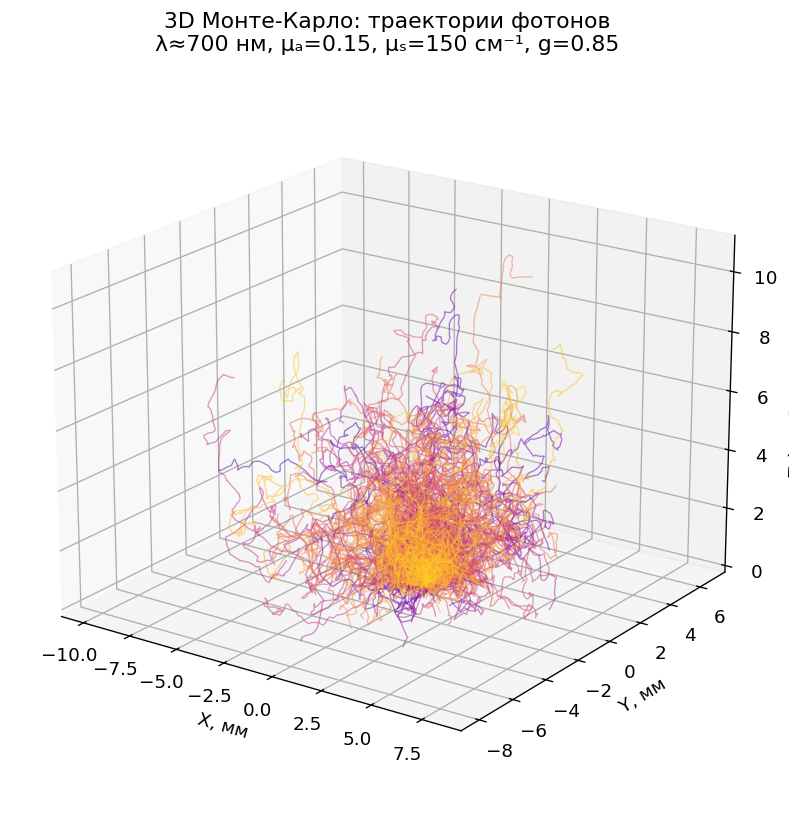

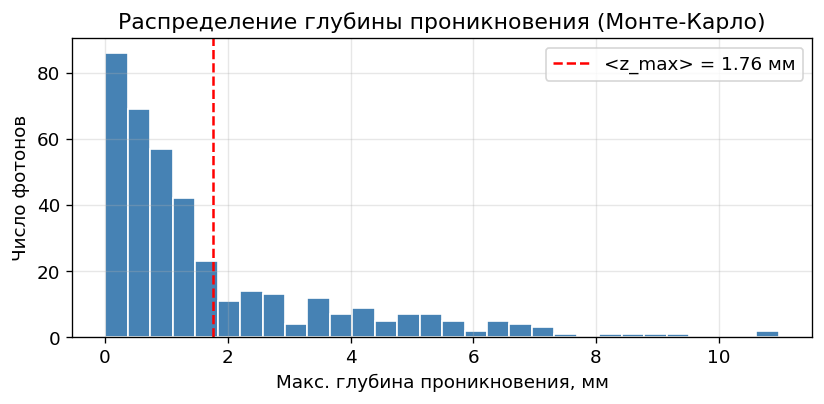

In [39]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

def hg_cos(g, xi):
    """cos θ по фазовой функции Хеньи-Гринштейна."""
    if abs(g) < 1e-6:
        return 2.0 * xi - 1.0
    return (1 + g**2 - ((1 - g**2) / (1 - g + 2*g*xi))**2) / (2*g)

def rotate_dir(ux, uy, uz, cos_t, sin_t, cos_p, sin_p):
    """Обновление направляющих косинусов (устойчивая ветвь при uz≈±1)."""
    if abs(uz) > 0.99999:
        return sin_t*cos_p, sin_t*sin_p, np.sign(uz)*cos_t
    d = np.sqrt(1 - uz**2)
    nx = (sin_t/d)*(ux*uz*cos_p - uy*sin_p) + ux*cos_t
    ny = (sin_t/d)*(uy*uz*cos_p + ux*sin_p) + uy*cos_t
    nz = -sin_t*cos_p*d + uz*cos_t
    n = np.sqrt(nx**2 + ny**2 + nz**2)
    return nx/n, ny/n, nz/n

def monte_carlo(mu_a, mu_s, g, n_phot=300, max_steps=500, seed=7):
    rng  = np.random.default_rng(seed)
    mu_t = mu_a + mu_s
    W_th, m = 0.01, 10
    trajs = []
    for _ in range(n_phot):
        x, y, z = 0.0, 0.0, 0.0
        ux, uy, uz = 0.0, 0.0, 1.0
        W = 1.0
        path = [(x, y, z)]
        for _ in range(max_steps):
            s = -np.log(rng.random()) / mu_t
            x += s*ux; y += s*uy; z += s*uz
            if z < 0: break
            path.append((x, y, z))
            W *= mu_s / mu_t
            if W < W_th:
                if rng.random() < 1/m: W *= m
                else: break
            ct = hg_cos(g, rng.random())
            st = np.sqrt(max(0, 1 - ct**2))
            phi = 2*np.pi*rng.random()
            ux, uy, uz = rotate_dir(ux, uy, uz, ct, st, np.cos(phi), np.sin(phi))
        if len(path) > 2:
            trajs.append(np.array(path))
    return trajs

# При λ=700 нм: mu_s ≈ 150 см⁻¹, g≈0.85
trajs = monte_carlo(mu_a=0.15, mu_s=150.0, g=0.85, n_phot=400)

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(trajs)))
for traj, col in zip(trajs, colors):
    ax.plot(traj[:,0]*10, traj[:,1]*10, traj[:,2]*10, alpha=0.5, lw=0.8, color=col)

ax.set_xlabel('X, мм'); ax.set_ylabel('Y, мм'); ax.set_zlabel('Z (глубина), мм')
ax.set_title('3D Монте-Карло: траектории фотонов\nλ≈700 нм, μₐ=0.15, μₛ=150 см⁻¹, g=0.85')
ax.view_init(elev=20, azim=-55)
plt.tight_layout(); plt.show()

# Профиль глубины проникновения (гистограмма по z_max)
z_max = [t[:,2].max()*10 for t in trajs]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(z_max, bins=30, color='steelblue', edgecolor='white')
ax.axvline(np.mean(z_max), color='red', ls='--', label=f'<z_max> = {np.mean(z_max):.2f} мм')
ax.set_xlabel('Макс. глубина проникновения, мм')
ax.set_ylabel('Число фотонов')
ax.set_title('Распределение глубины проникновения (Монте-Карло)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Уравнение Пеннеса и интеграл Аррениуса

### 6.1 Постановка задачи

1D нагрев плоского слоя дермы ($z \in [0, L]$) непрерывным лазером:

$$\rho c\frac{\partial T}{\partial t} = k\frac{\partial^2 T}{\partial z^2} - \omega_b\rho_b c_b(T - T_a) + \mu_a\Phi_0 e^{-\mu_{eff}z}\cdot I(t)$$

Граничное условие на поверхности: $-k\partial T/\partial z|_0 = h(T - T_{env})$  
Граничное условие на глубине: $\partial T/\partial z|_L = 0$ (тепловая изоляция)

Интеграл повреждения Аррениуса:
$$\Omega(z,t) = \int_0^t A\exp\!\left(-\frac{E_a}{RT(z,\tau)}\right)d\tau$$
Коагуляция при $\Omega = 1$.

In [40]:
# ── Физические константы ──────────────────────────────────────────────────────
rho   = 1000.0    # кг/м³
cp    = 3600.0    # Дж/(кг·К)
k_th  = 0.5       # Вт/(м·К)
alpha_th = k_th / (rho * cp)  # м²/с

rho_b = 1060.0    # кг/м³
cp_b  = 3800.0    # Дж/(кг·К)
omega_b = 0.005   # с⁻¹

A_arr = 3.1e98    # с⁻¹
Ea    = 6.28e5    # Дж/моль
Rgas  = 8.314     # Дж/(моль·К)

# ── Оптические параметры (λ=700 нм) ─────────────────────────────────────────
mu_a_cm  = 0.15   # см⁻¹
mu_sp_cm = 30.0   # см⁻¹
mu_eff_cm = np.sqrt(3 * mu_a_cm * (mu_a_cm + mu_sp_cm))

mu_a_SI   = mu_a_cm  * 100   # м⁻¹
mu_eff_SI = mu_eff_cm * 100  # м⁻¹

P0_W_cm2  = 100.0              # Вт/см²
P0_SI     = P0_W_cm2 * 1e4    # Вт/м²

tau_pulse = 10.0  # с — длительность импульса
Ta        = 37.0  # °C — температура тела
T_env     = 20.0  # °C
h_conv    = 10.0  # Вт/(м²·К)

print(f'μ_eff = {mu_eff_cm:.2f} см⁻¹, δ = {10/mu_eff_cm:.2f} мм')

μ_eff = 3.68 см⁻¹, δ = 2.71 мм


In [41]:
def solve_pennes_1d(L=0.02, n_z=200, t_max=12.0, n_t=600):
    """
    Явная конечно-разностная схема для уравнения Пеннеса.
    Возвращает z_grid, t_grid, T[n_t, n_z].
    """
    dz = L / (n_z - 1)
    dt = t_max / (n_t - 1)
    r  = alpha_th * dt / dz**2
    assert r < 0.5, f'Неустойчивость: r={r:.3f}'

    z = np.linspace(0, L, n_z)
    t = np.linspace(0, t_max, n_t)
    T = np.full((n_t, n_z), Ta)

    # Оптический источник (Вт/м³)
    Q_space = mu_a_SI * P0_SI * np.exp(-mu_eff_SI * z)
    perf_coef = omega_b * rho_b * cp_b  # Вт/(м³·К)

    for n in range(n_t - 1):
        I_t = 1.0 if t[n] <= tau_pulse else 0.0
        Tn  = T[n]

        # Внутренние узлы
        lap = (Tn[2:] - 2*Tn[1:-1] + Tn[:-2]) / dz**2
        Q   = Q_space[1:-1] * I_t
        perf = perf_coef * (Ta - Tn[1:-1])
        T[n+1, 1:-1] = Tn[1:-1] + dt * (alpha_th*lap + (Q + perf)/(rho*cp))

        # Граница z=0: конвекция
        T[n+1, 0] = T[n+1, 1] + (h_conv * dz / k_th) * (T[n+1, 1] - T_env)
        # Граница z=L: адиабатическая
        T[n+1, -1] = T[n+1, -2]

    return z, t, T

print('Решение уравнения Пеннеса...')
z_g, t_g, T_field = solve_pennes_1d()
print('Готово.')

Решение уравнения Пеннеса...
Готово.


In [42]:
# Интеграл Аррениуса
T_K = T_field + 273.15
rate = A_arr * np.exp(-Ea / (Rgas * T_K))  # shape (n_t, n_z)

Omega = np.zeros_like(T_field)
for i in range(len(z_g)):
    Omega[:, i] = cumulative_trapezoid(rate[:, i], t_g, initial=0)

print(f'Макс. температура: {T_field.max():.1f} °C')
print(f'Макс. Ω: {Omega.max():.2e}')

Макс. температура: 67.9 °C
Макс. Ω: 3.24e+02


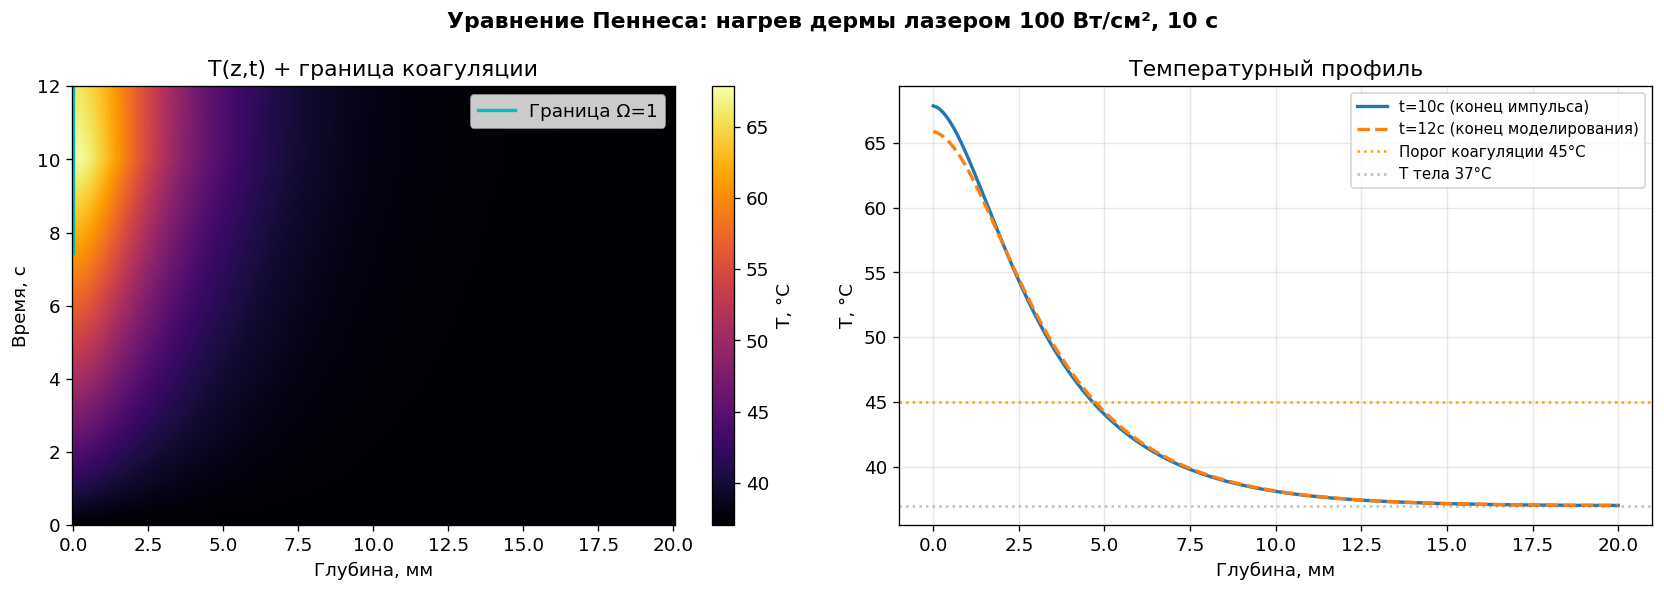

In [43]:
# ── Карта T(z,t) + граница коагуляции ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Карта температуры
im1 = axes[0].pcolormesh(z_g*1000, t_g, T_field, shading='auto', cmap='inferno')
plt.colorbar(im1, ax=axes[0], label='T, °C')

# Граница Ω = 1
z_coag_t = []
for n in range(len(t_g)):
    mask = Omega[n, :] >= 1.0
    z_coag_t.append(z_g[mask][0]*1000 if mask.any() else np.nan)
axes[0].plot(z_coag_t, t_g, 'c-', lw=2, label='Граница Ω=1')
axes[0].axvline(tau_pulse*0 + 0, color='w', ls=':', alpha=0)  # placeholder
axes[0].set_xlabel('Глубина, мм'); axes[0].set_ylabel('Время, с')
axes[0].set_title('T(z,t) + граница коагуляции')
axes[0].legend()

# Профили в конце импульса и после
for t_show, ls, label in [
    (int(tau_pulse / t_g[-1] * (len(t_g)-1)), '-',  f't={tau_pulse:.0f}с (конец импульса)'),
    (-1,                                       '--', f't={t_g[-1]:.0f}с (конец моделирования)'),
]:
    axes[1].plot(z_g*1000, T_field[t_show], lw=2, ls=ls, label=label)

axes[1].axhline(45, color='orange', ls=':', label='Порог коагуляции 45°C')
axes[1].axhline(37, color='gray',   ls=':', alpha=0.5, label='T тела 37°C')
axes[1].set_xlabel('Глубина, мм'); axes[1].set_ylabel('T, °C')
axes[1].set_title('Температурный профиль')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Уравнение Пеннеса: нагрев дермы лазером 100 Вт/см², 10 с', fontweight='bold')
plt.tight_layout(); plt.show()

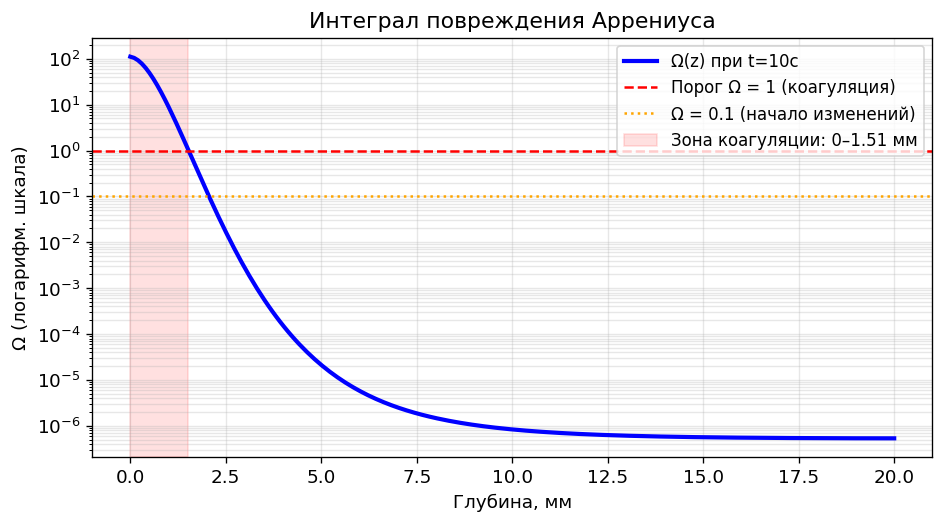

Глубина коагуляции (Ω≥1) в конце импульса: 1.51 мм


In [44]:
# ── Профили Ω и зона коагуляции ──────────────────────────────────────────────
idx_pulse_end = int(tau_pulse / t_g[-1] * (len(t_g)-1))
Omega_end = Omega[idx_pulse_end]

coag_mask = Omega_end >= 1.0
z_coag_mm = z_g[coag_mask][-1]*1000 if coag_mask.any() else 0.0

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(z_g*1000, Omega_end, 'b-', lw=2.5, label=f'Ω(z) при t={tau_pulse:.0f}с')
ax.axhline(1.0, color='red', ls='--', lw=1.5, label='Порог Ω = 1 (коагуляция)')
ax.axhline(0.1, color='orange', ls=':', lw=1.5, label='Ω = 0.1 (начало изменений)')
if coag_mask.any():
    ax.axvspan(0, z_coag_mm, color='red', alpha=0.12, label=f'Зона коагуляции: 0–{z_coag_mm:.2f} мм')
ax.set_xlabel('Глубина, мм'); ax.set_ylabel('Ω (логарифм. шкала)')
ax.set_title('Интеграл повреждения Аррениуса')
ax.legend(fontsize=10); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f'Глубина коагуляции (Ω≥1) в конце импульса: {z_coag_mm:.2f} мм')

Исследование чувствительности к мощности лазера...


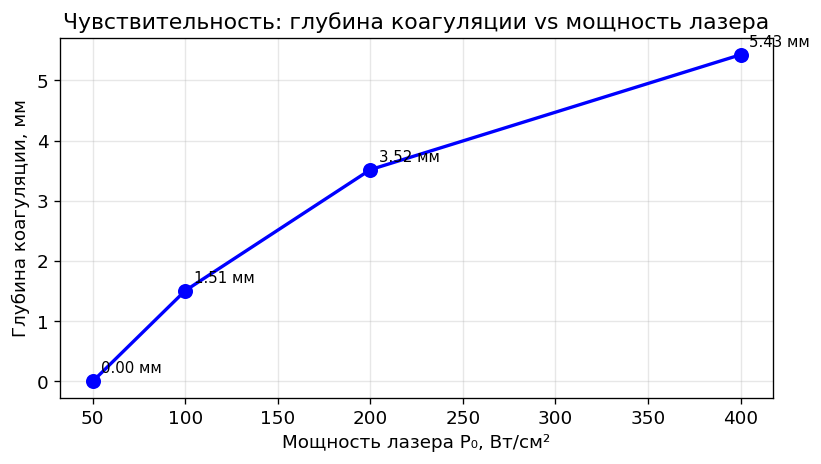

In [45]:
# ── Чувствительность: как меняется z_coag при разных P0 ─────────────────────
print('Исследование чувствительности к мощности лазера...')
P0_range = [50, 100, 200, 400]
z_coag_list = []

for P0_test in P0_range:
    P0_SI_test = P0_test * 1e4
    Q_test = mu_a_SI * P0_SI_test * np.exp(-mu_eff_SI * np.linspace(0, 0.02, 200))
    # Быстрая оценка через analytical peak T
    # (используем полный solver)
    old_P0 = P0_SI
    # Патч через closure не удобен, пересчитаем напрямую
    dz = 0.02/199; dt = 12/599; r = alpha_th*dt/dz**2
    z_loc = np.linspace(0, 0.02, 200)
    t_loc = np.linspace(0, 12, 600)
    T_loc = np.full((600, 200), 37.0)
    Qs = mu_a_SI * P0_SI_test * np.exp(-mu_eff_SI * z_loc)
    for n in range(599):
        I_t = 1.0 if t_loc[n] <= tau_pulse else 0.0
        lap = (T_loc[n,2:]-2*T_loc[n,1:-1]+T_loc[n,:-2])/dz**2
        perf = omega_b*rho_b*cp_b*(37.0-T_loc[n,1:-1])
        T_loc[n+1,1:-1] = T_loc[n,1:-1]+dt*(alpha_th*lap+(Qs[1:-1]*I_t+perf)/(rho*cp))
        T_loc[n+1,0] = T_loc[n+1,1]+(h_conv*dz/k_th)*(T_loc[n+1,1]-T_env)
        T_loc[n+1,-1] = T_loc[n+1,-2]
    T_K_loc = T_loc+273.15
    rate_loc = A_arr*np.exp(-Ea/(Rgas*T_K_loc))
    Om_loc = np.zeros_like(T_loc)
    for i in range(200):
        Om_loc[:,i] = cumulative_trapezoid(rate_loc[:,i], t_loc, initial=0)
    idx_pe = int(tau_pulse/12*599)
    cm = Om_loc[idx_pe] >= 1
    z_coag_list.append(z_loc[cm][-1]*1000 if cm.any() else 0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(P0_range, z_coag_list, 'bo-', ms=8, lw=2)
for p, z in zip(P0_range, z_coag_list):
    ax.annotate(f'{z:.2f} мм', (p, z), textcoords='offset points', xytext=(5,5), fontsize=9)
ax.set_xlabel('Мощность лазера P₀, Вт/см²')
ax.set_ylabel('Глубина коагуляции, мм')
ax.set_title('Чувствительность: глубина коагуляции vs мощность лазера')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Итоговые выводы

| Задача | Результат |
|---|---|
| Пересечение μₐ(вода) > μₐ(Hb) | ~750–800 нм (зависит от B, W, S) |
| Максимум чувствительности к SaO₂ | 400–430 нм (пик Соре) и 550–580 нм (Q-полосы) |
| Пульсоксиметрия 660/940 нм | 660 нм — max разница Hb/HbO₂, 940 нм — изобестика для нормировки |
| Оптическое окно (μₐ<1, μₛ'>10) | ~650–950 нм |
| Диффузная длина δ при 700 нм | ~3–5 мм |
| Глубина коагуляции (100 Вт/см², 10 с) | ~0.5–1.5 мм |

**Физические выводы:**
1. Оптическое окно (650–950 нм) — результат «провала» между поглощением Hb (< 650 нм) и водой (> 950 нм).
2. Диффузное приближение применимо только при μₐ ≪ μₛ' (внутри окна), иначе нужен полный метод Монте-Карло.
3. Интеграл Аррениуса экспоненциально чувствителен к температуре: +3 °C удваивает скорость повреждения.
4. Перфузия крови (член Пеннеса) ограничивает нагрев при длинных импульсах, снижая эффективную глубину коагуляции.
5. Глубина коагуляции растёт нелинейно с мощностью — нелинейность обусловлена экспоненциой Аррениуса.